In [1]:
import os
import numpy as np
import hyperspy.api as hs

In [2]:
import colorcet as cc
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import seaborn as sns
from matplotlib.gridspec import GridSpec
import stem_analysis.plot as saplt

fluorescent_green = LinearSegmentedColormap.from_list(
    "black_fluorescent_green_white",
    ["black", "#39FF14", "white"],
)


In [3]:
from tifffile import imread, imwrite

In [4]:
from skimage.filters import gaussian, window
from skimage.feature import peak_local_max, match_template
from scipy.ndimage import median_filter, rotate,shift
from skimage.transform import AffineTransform, warp


In [5]:
import atomap.api as am

/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


In [6]:
import PyQt5 

In [7]:
%matplotlib widget

# Load Data

In [8]:
work_dir = '/Users/nihy/Desktop/Working Data/DRX/Zone 211/Shear Corrected/Analysis'

In [9]:
ptyrad_file = os.path.join(work_dir, "object_phase_cropped.tif")

In [10]:
#scan_file = '/Users/nihy/Desktop/Working Data/EuAl4/Ptycho/Cryo Zone 001/11/STEM SI.dm4'

In [11]:
#scan = hs.load(scan_file)[-1].data


In [12]:
indr, indc = np.random.randint(0, 100, 2)
dp_single = scan[indr-2:indr + 2, indc - 2 : indc + 2].mean((0,1))

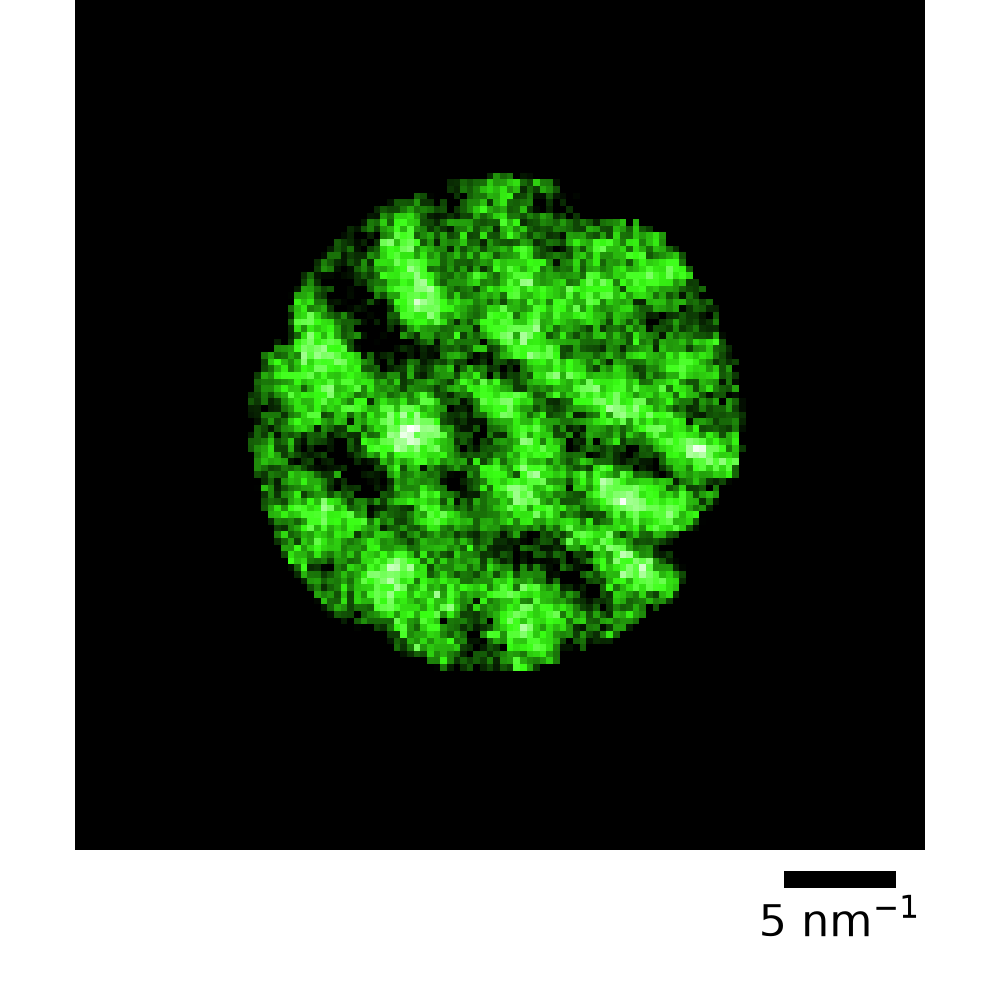

In [13]:
saplt.PlotDiff(dp_single, 0.297, cmap = fluorescent_green, norm = 'linear', vmin_percentile = 75, vmax_percentile = 100)
plt.savefig(os.path.join(work_dir, "rand_dp_single.svg"), dpi=300, pad_inches = 0)

In [12]:
img_stack = imread(ptyrad_file)
img_stack.shape

(26, 363, 363)

In [13]:
dx, dy, dz = 0.01277, 0.01277, 1 # in nm

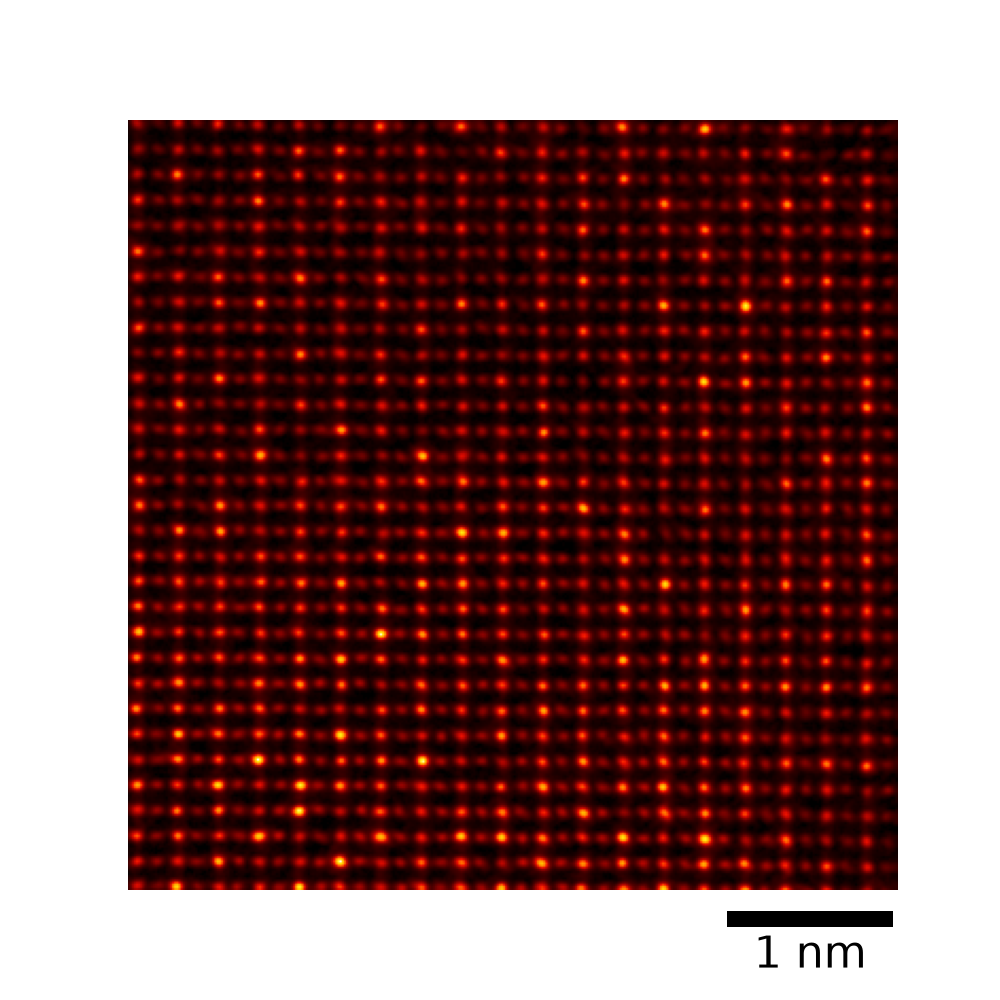

In [14]:
saplt.PlotImage(img_stack.sum(0), dx, cmap=cc.cm.fire, vmin_percentile=0, vmax_percentile=100)
plt.savefig(
    os.path.join(work_dir, "ptyrad_sum_fire.svg"),
    dpi = 300,
    pad_inches = 0
)

In [15]:
img_stack.sum(0).min(), img_stack.sum(0).max(), 2*np.pi

(np.float32(0.0), np.float32(5.3497963), 6.283185307179586)

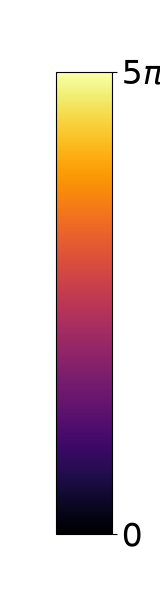

In [16]:
norm = Normalize(vmin=0, vmax=5* np.pi)
sm = plt.cm.ScalarMappable(norm=norm, cmap="inferno")
sm.set_array([])

fig, cax = plt.subplots(figsize=(1.6, 6))
fig.subplots_adjust(left=0.35, right=0.7)

cbar = fig.colorbar(sm, cax=cax)
cax.set_yticks([0, 5*np.pi])
cax.set_yticklabels([0, r"$5\pi$"], fontsize=24)

fig.savefig(
   os.path.join(work_dir, "standalone_colorbar.svg"),
   dpi=300,
   bbox_inches="tight",
   transparent=True,
)
plt.show()

# FFT

In [17]:
dq = 1/(img_stack.shape[1]*dx) # in 1/nm
dq

0.21572599347213145

In [18]:
w = window('hann', img_stack.shape)

In [19]:
fft_3d_abs = np.abs(np.fft.fftshift(np.fft.fftn(img_stack*w)))
fft_3d_abs.shape

(26, 363, 363)

In [20]:
pz, px, py = img_stack.shape

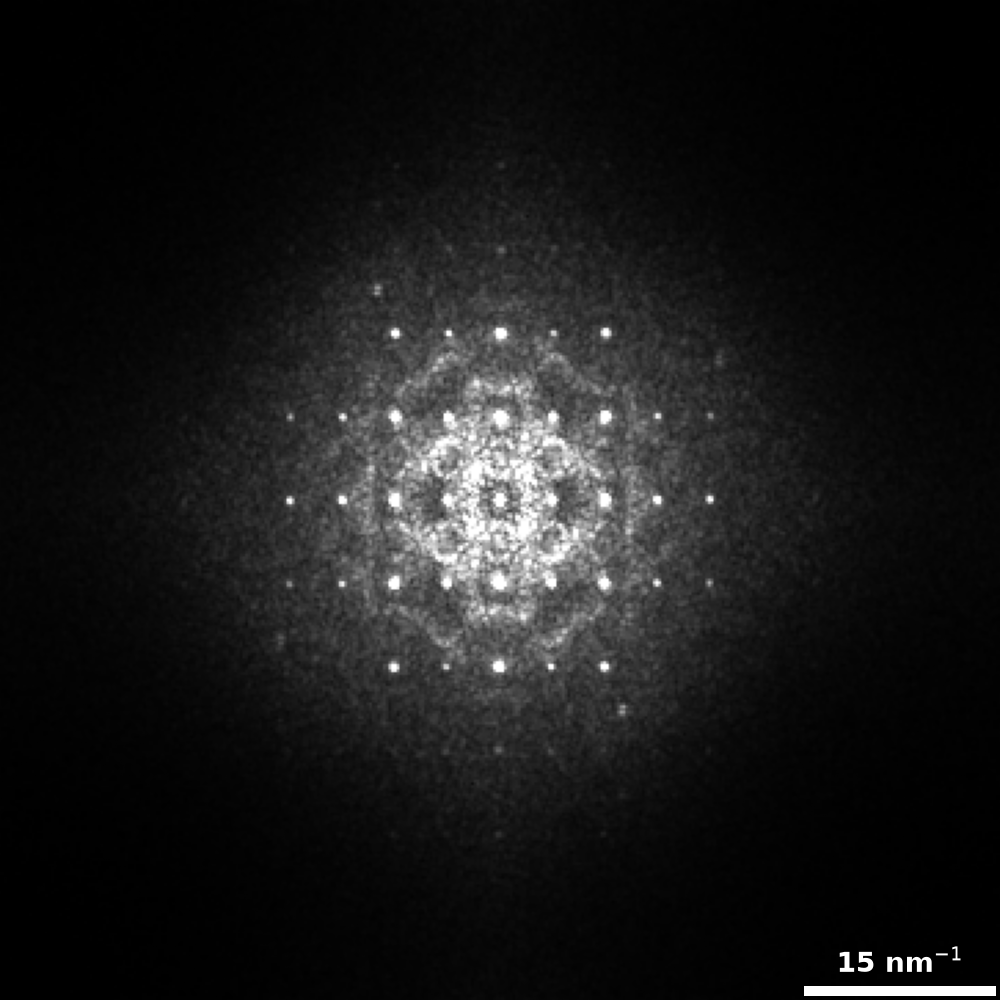

In [21]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(fft_3d_abs.sum(0), cmap='gray', vmax = 1000)
ax = plt.gca()
sbar = ScaleBar(
    dq,
    '1/nm',
    dimension = "si-length-reciprocal",
    location = 'lower right',
    length_fraction = 0.25,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis("off")
plt.savefig(os.path.join(work_dir, "ptyrad_fft.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

# Find Lattice Points by a combined routine of template matching and lattice fitting

# Template matching

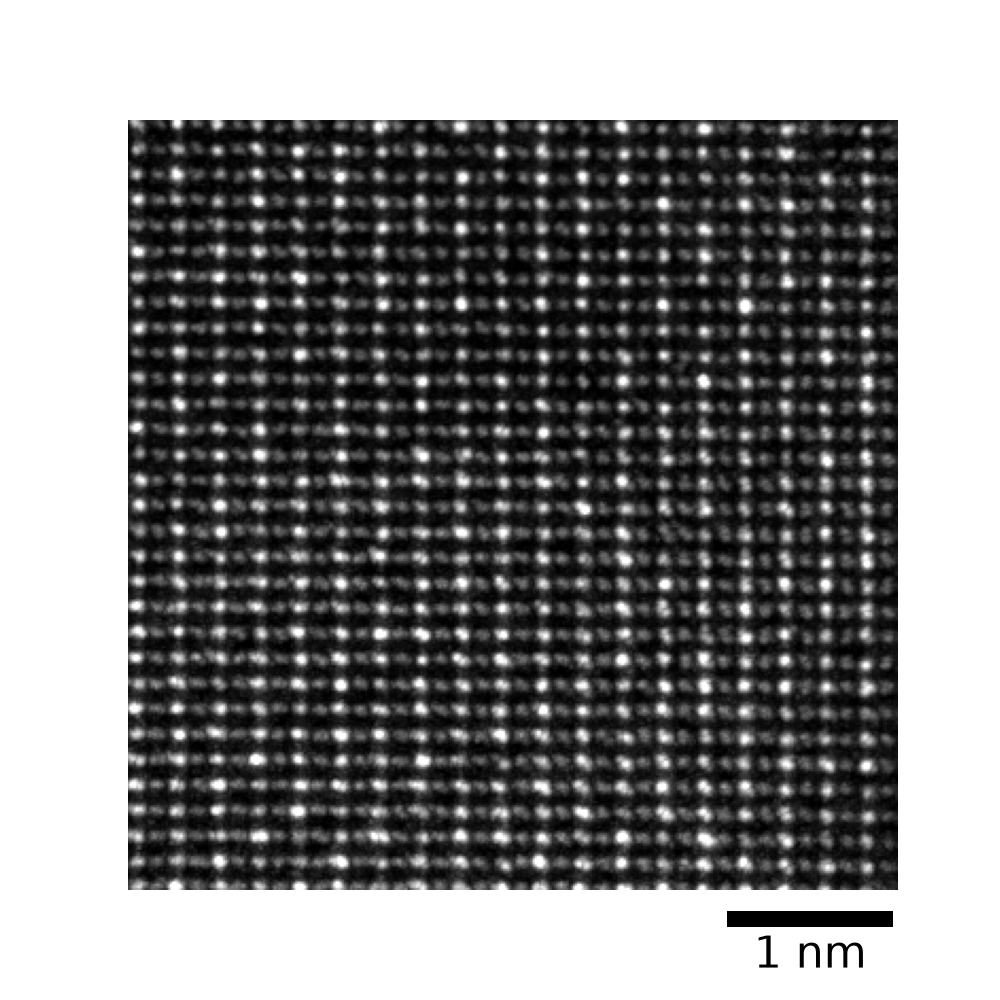

In [22]:
saplt.PlotImage(img_stack.max(0), dx, cmap='gray')

In [23]:
template = img_stack.sum(0)[51:51+25, 88:88+25]

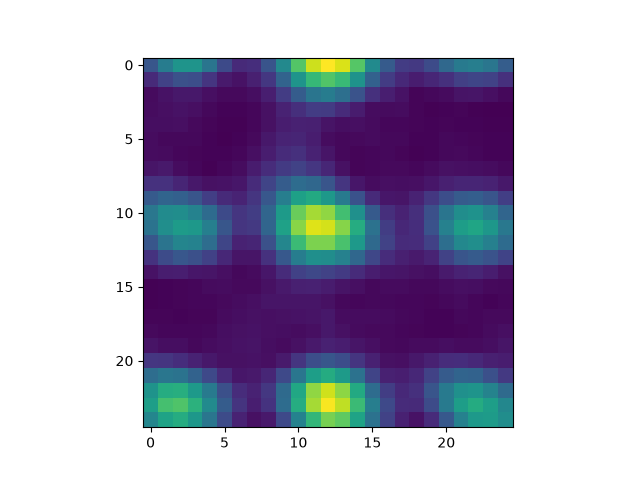

In [24]:
plt.figure()
plt.imshow(template)

In [25]:
matched = match_template(img_stack.sum(0), template, pad_input=True)

In [26]:
peaks = peak_local_max(matched, min_distance=7, threshold_abs=0.6)

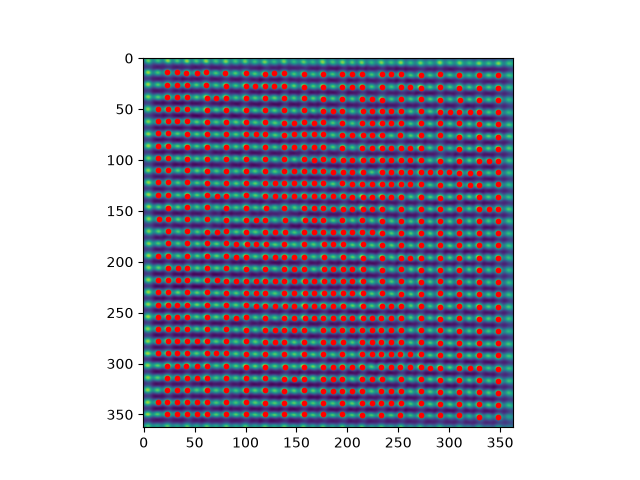

In [27]:
plt.figure()
plt.imshow(matched)
plt.scatter(peaks[:, 1], peaks[:, 0], color='r', s=10)

# Atomap Lattice Fitting

In [28]:
import hyperspy.api as hs

In [29]:
matched_hs = hs.signals.Signal2D(matched)

In [30]:
s_peaks = am.get_feature_separation(matched_hs, separation_range=(2, 20), show_progressbar=False)
s_peaks.plot()

In [32]:
lattice_positions = am.get_atom_positions(matched_hs, separation=9, threshold_rel=0.5)

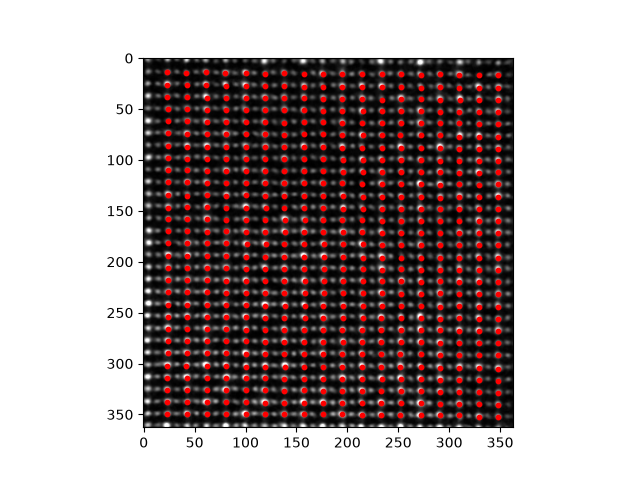

In [33]:
plt.figure()
plt.imshow(img_stack.sum(0), cmap='gray', vmin = 0, vmax = 1*np.pi)
plt.scatter(lattice_positions[:, 0], lattice_positions[:, 1], color='r', s=10)

In [34]:
cation_positions = lattice_positions + [0, 0]
anion_positions = lattice_positions + [9, 0]

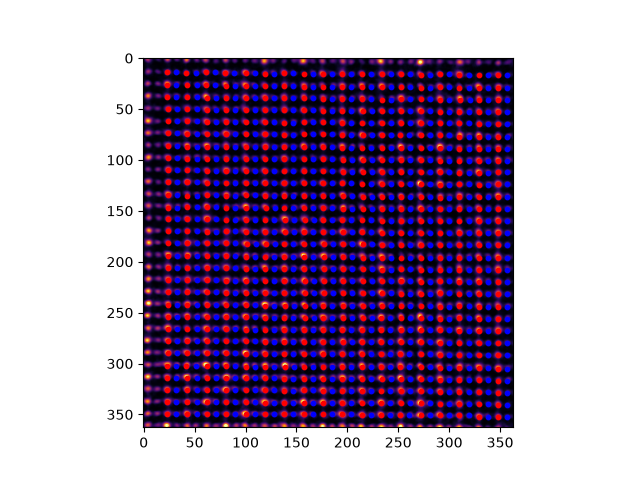

In [35]:
plt.figure()
plt.imshow(img_stack.sum(0), cmap='inferno', vmax = 4, vmin = 0)
plt.scatter(cation_positions[:, 0], cation_positions[:, 1], color='r', s=10)
plt.scatter(anion_positions[:, 0], anion_positions[:, 1], color='b', s=10)

In [36]:
sublattice_cation = am.Sublattice(cation_positions, image = img_stack.sum(0))
sublattice_anion = am.Sublattice(anion_positions, image = img_stack.sum(0))

In [37]:
sublattice_cation.find_nearest_neighbors()
sublattice_cation.refine_atom_positions_using_center_of_mass()
sublattice_cation.refine_atom_positions_using_2d_gaussian()

Gaussian fitting: 100%|██████████| 522/522 [00:01<00:00, 324.91it/s]


In [38]:
sublattice_anion.find_nearest_neighbors()
sublattice_anion.refine_atom_positions_using_center_of_mass()
sublattice_anion.refine_atom_positions_using_2d_gaussian()

Gaussian fitting: 100%|██████████| 522/522 [00:01<00:00, 351.02it/s]


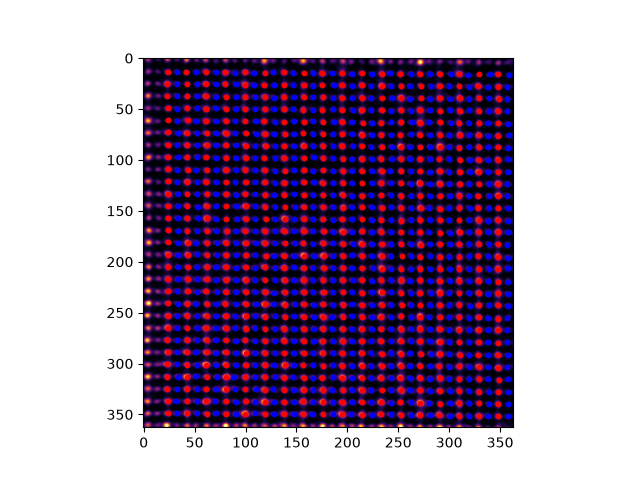

In [39]:
plt.figure()
plt.imshow(img_stack.sum(0), cmap='inferno', vmax = 4, vmin = 0)
plt.scatter(sublattice_cation.atom_positions[:, 0], sublattice_cation.atom_positions[:, 1], color='r', s=10)
plt.scatter(sublattice_anion.atom_positions[:, 0], sublattice_anion.atom_positions[:, 1], color='b', s=10)

## Save Intermediate Result

In [40]:
sum_phase_lattice = am.Atom_Lattice(image=img_stack.sum(0), name='sum phase', sublattice_list=[sublattice_cation, sublattice_anion])

In [41]:
sum_phase_lattice.save(os.path.join(work_dir,"sum_phase_lattice.hdf5"), overwrite=True)

# Fit Layer-by-Layer anion positions
Using Anion because of less variations of intensities

In [42]:
slice_range = np.arange(0, pz)
slice_range.shape

(26,)

In [43]:
sublattice_anion_layer_by_layer = []
for i in slice_range:
    s_anion = am.Sublattice(sublattice_anion.atom_positions, image = img_stack[i])
    s_anion.find_nearest_neighbors()
    s_anion.refine_atom_positions_using_center_of_mass()
    #s_anion.refine_atom_positions_using_2d_gaussian()
    sublattice_anion_layer_by_layer.append(s_anion)

Center of mass:   0%|          | 0/522 [00:00<?, ?it/s]/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/atomap/atom_finding_refining.py:604: RuntimeWarning: invalid value encountered in divide
  arr = arr / np.sum(arr, axis=(-1, -2))
Center of mass: 100%|██████████| 522/522 [00:00<00:00, 55331.87it/s]


In [44]:
sublattice_cation_layer_by_layer = []
for i in slice_range:
    s_cation = am.Sublattice(cation_positions, image = img_stack[i])
    s_cation.find_nearest_neighbors()
    s_cation.refine_atom_positions_using_center_of_mass()
    #s_cation.refine_atom_positions_using_2d_gaussian()
    sublattice_cation_layer_by_layer.append(s_cation)

Center of mass: 100%|██████████| 522/522 [00:00<00:00, 52151.56it/s]


In [45]:
sublattice_anion_layer_by_layer_pos = np.array([s_anion.atom_positions for s_anion in sublattice_anion_layer_by_layer])
sublattice_anion_layer_by_layer_pos.shape

(26, 522, 2)

In [46]:
sublattice_cation_layer_by_layer_pos = np.array([s_cation.atom_positions for s_cation in sublattice_cation_layer_by_layer])
sublattice_cation_layer_by_layer_pos.shape

(26, 522, 2)

In [47]:
sublattice_anion_layer_by_layer_pos_shift = sublattice_anion_layer_by_layer_pos - np.mean(sublattice_anion_layer_by_layer_pos, axis = 0, keepdims = True)
sublattice_cation_layer_by_layer_pos_shift = sublattice_cation_layer_by_layer_pos - np.mean(sublattice_cation_layer_by_layer_pos, axis = 0, keepdims = True)

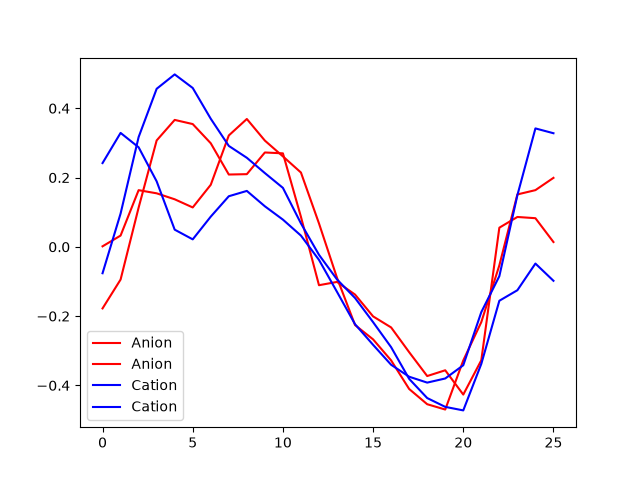

In [48]:
plt.figure()
plt.plot(np.nanmedian(sublattice_anion_layer_by_layer_pos_shift, axis=1), c ='r', label = 'Anion')
plt.plot(np.nanmedian(sublattice_cation_layer_by_layer_pos_shift, axis=1), c ='b', label = 'Cation')
plt.legend()

In [49]:
z_fit = np.arange(5,20)
cation_x = cation_positions[5:20,0]
cation_y = cation_positions[5:20,1]
coefficients_x = np.polyfit(z_fit, cation_x, 1)
coefficients_y = np.polyfit(z_fit, cation_y, 1)

In [50]:
px, py = np.poly1d(coefficients_x), np.poly1d(coefficients_y)

fitted_cation_x = px(np.arange(0,pz))
fitted_cation_y = py(np.arange(0,pz))
fitted_cation = np.column_stack((fitted_cation_x, fitted_cation_y))

In [51]:
# Shift image due to the mistilt

In [52]:
img_stack_shifted = np.zeros_like(img_stack)
for i in slice_range:
    img_stack_shifted[i] = shift(img_stack[i], shift = -np.nanmedian(sublattice_cation_layer_by_layer_pos_shift, axis=1)[i][::-1], order = 1)
img_stack_shifted.min(), img_stack_shifted.max()    

(np.float32(0.0), np.float32(0.5366101))

In [53]:
sum_phase_aligned = np.nansum(img_stack_shifted, axis=0)

In [54]:
fft_3d_abs = np.abs(np.fft.fftshift(np.fft.fftn(img_stack_shifted*w)))
fft_3d_abs.shape

(26, 363, 363)

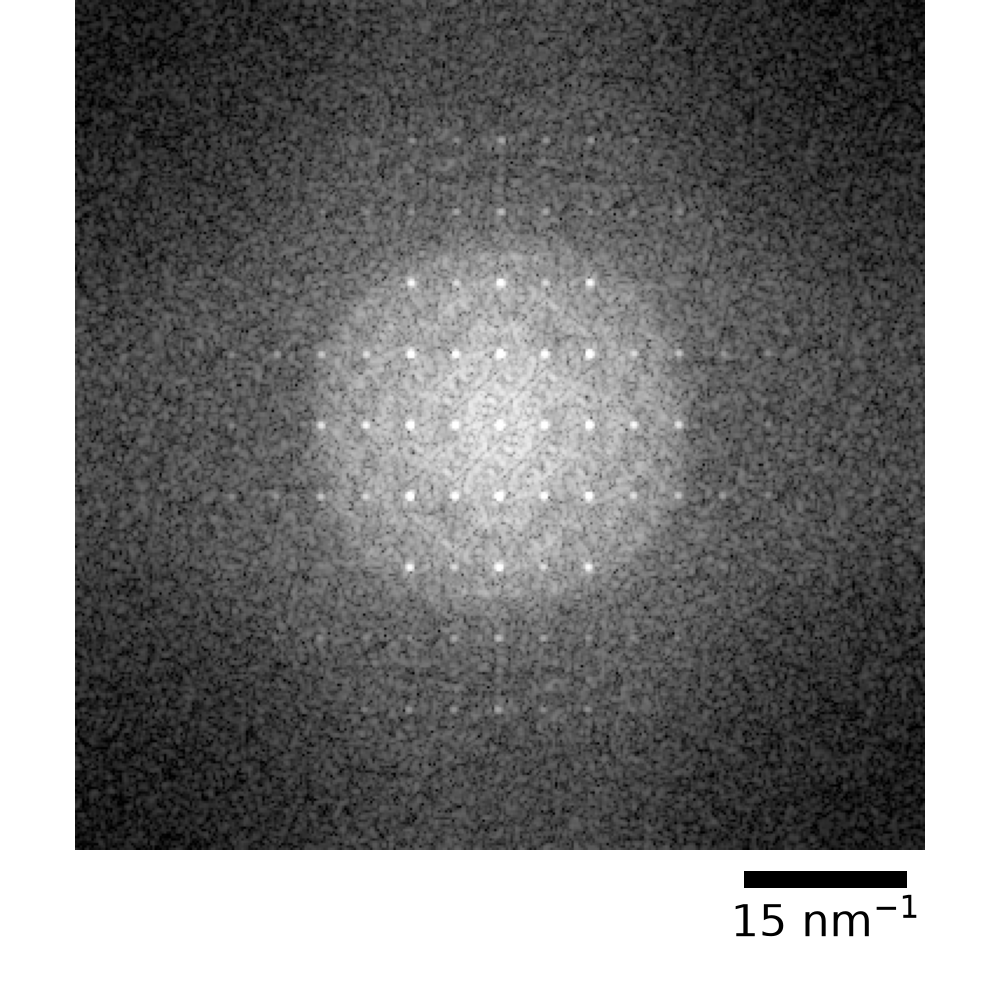

In [55]:
saplt.PlotDiff(fft_3d_abs[pz//2], dq, cmap = 'gray')
plt.savefig(os.path.join(work_dir, 'fft_3d_abs.svg'),
            dpi = 300,
            pad_inches = 0,
            transparent = True)

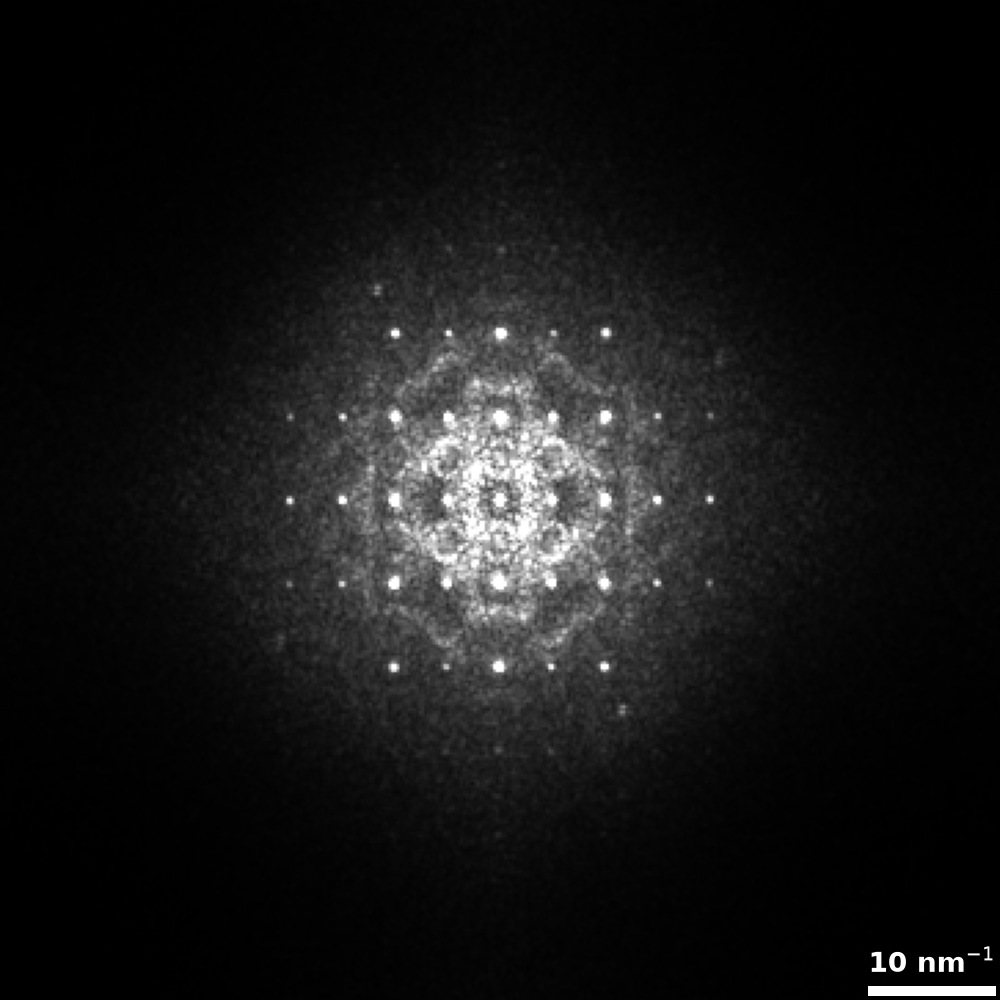

In [56]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(fft_3d_abs.sum(0), cmap='gray', vmax = 1000)
ax = plt.gca()
sbar = ScaleBar(
    dq,
    '1/nm',
    dimension = "si-length-reciprocal",
    location = 'lower right',
    fixed_value = 10,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis("off")
plt.savefig(os.path.join(work_dir, "ptyrad_fft_aligned.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

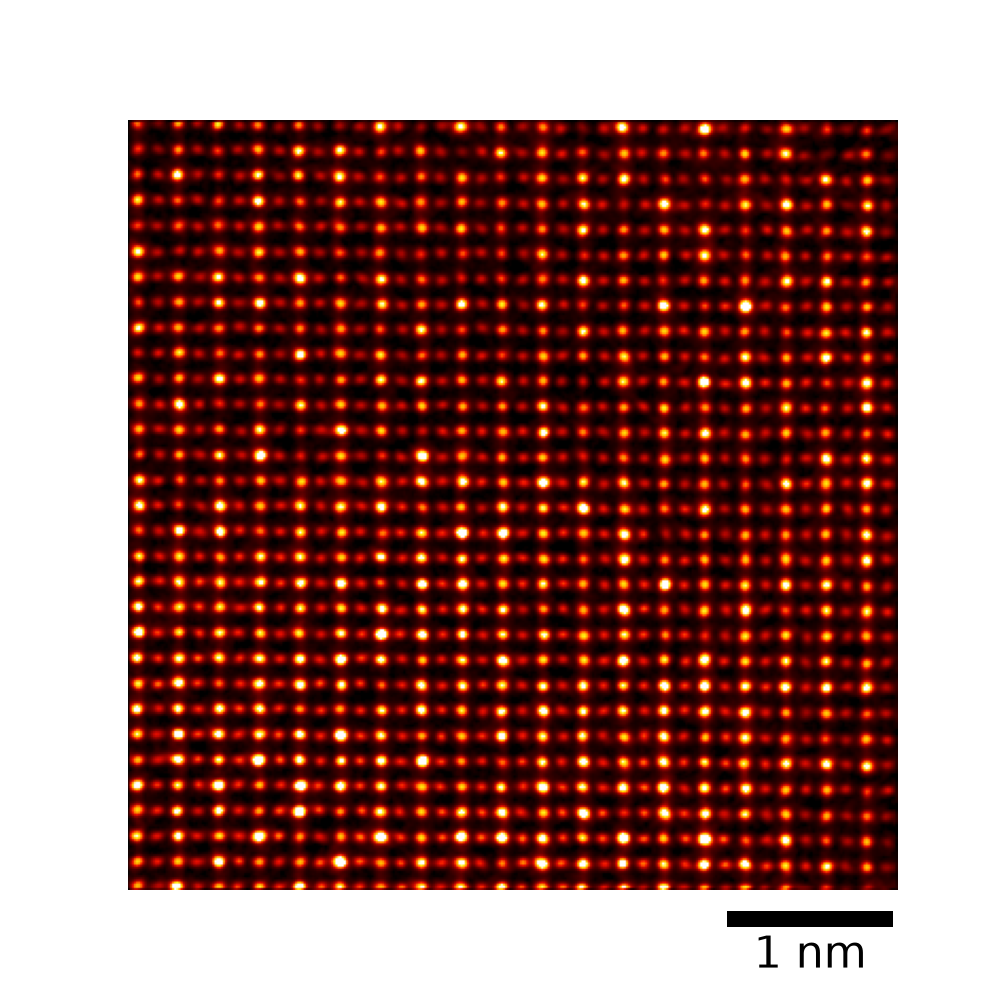

In [57]:
saplt.PlotImage(sum_phase_aligned, dx, cmap = cc.cm.fire)
plt.savefig(os.path.join(work_dir, "ptyrad_sum_aligned.svg"), 
            dpi = 300, 
            pad_inches = 0,
            transparent = True)

In [58]:
imwrite(os.path.join(work_dir,"object_phase_cropped_aligned_0_{}.tif".format(pz)), img_stack_shifted.astype(np.float32))

In [58]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig_animation, ax_animation = plt.subplots(figsize=(6, 6))
im_animation = ax_animation.imshow(
    img_stack_shifted[0],
    cmap="inferno",
    vmin=0,
    vmax=np.percentile(img_stack_shifted, 99.5),
)
ax_animation.axis("off")
title_animation = ax_animation.set_title("Slice 0", color="white")

def update_animation(frame):
    im_animation.set_data(img_stack_shifted[frame])
    title_animation.set_text(f"Slice {frame}")
    return im_animation, title_animation

animation = FuncAnimation(
    fig_animation,
    update_animation,
    frames=img_stack_shifted.shape[0],
    interval=150,
    blit=True,
)

animation_path = os.path.join(work_dir, "object_phase_cropped_aligned_0_30.gif")
animation.save(
    animation_path,
    writer=PillowWriter(fps=7), 
    dpi = 300
)

plt.close(fig_animation)
print(f"Saved animation to: {animation_path}")

Saved animation to: /Users/nihy/Desktop/Working Data/EuAl4/Cryo Zone 001/11/1/object_phase_cropped_aligned_0_60.gif


In [89]:
cc.colorwheel[::256//4]

['#2e21ea', '#ef55f1', '#f0ed35', '#31ac28']